# Employee Attrition Analysis and Prediction Using Machine Learning
## MCA Major Project


In [1]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,roc_curve,roc_auc_score
plt.style.use('ggplot')
print("Libraries Loaded")

Libraries Loaded


## Load Dataset

In [2]:
df=pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


## Explore Dataset

In [4]:
print(df.shape)
df.info()
df.describe()

(1470, 35)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel     

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


## Missing & Duplicate Values

In [5]:
print(df.isnull().sum())
print('Duplicates:',df.duplicated().sum())

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

## Attrition Distribution

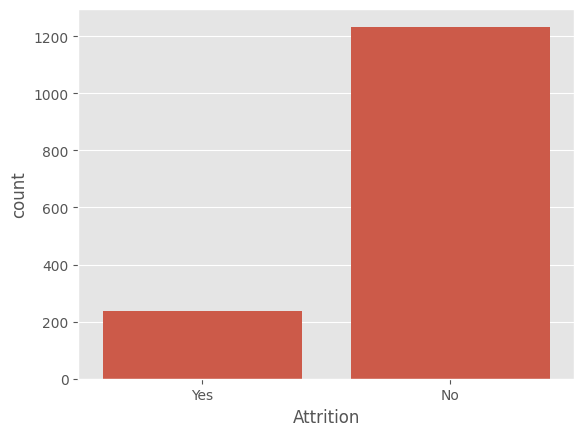

In [6]:
sns.countplot(x='Attrition',data=df)
plt.show()

## Correlation Heatmap

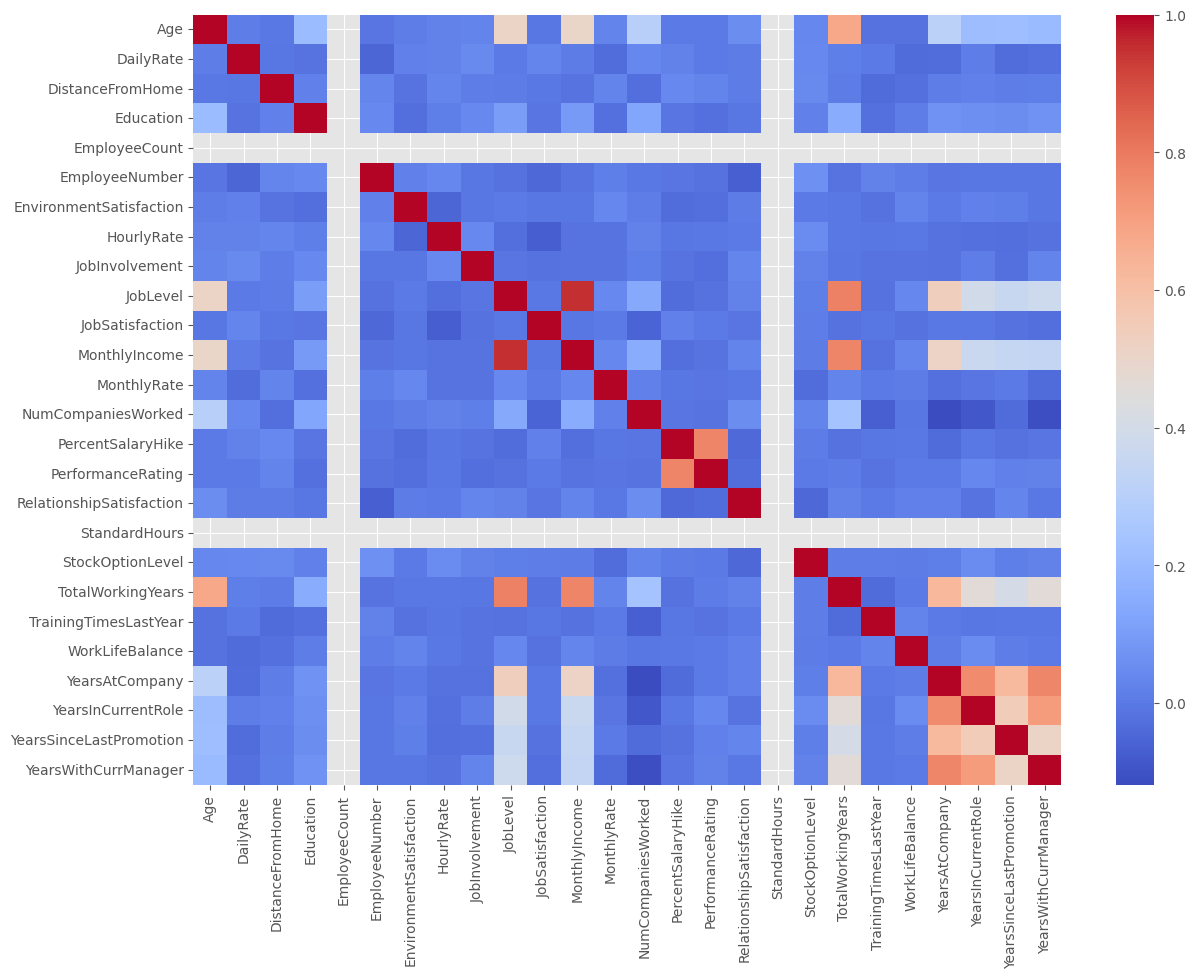

In [7]:
plt.figure(figsize=(14,10))
sns.heatmap(df.corr(numeric_only=True),cmap='coolwarm')
plt.show()

#  Data Preprocessing and Exploratory Data Analysis (EDA)

In this section we clean the dataset, encode categorical variables, and perform Exploratory Data Analysis to understand the important factors affecting employee attrition.

Check Data Types

In [8]:
print(df.dtypes)

Age                          int64
Attrition                   object
BusinessTravel              object
DailyRate                    int64
Department                  object
DistanceFromHome             int64
Education                    int64
EducationField              object
EmployeeCount                int64
EmployeeNumber               int64
EnvironmentSatisfaction      int64
Gender                      object
HourlyRate                   int64
JobInvolvement               int64
JobLevel                     int64
JobRole                     object
JobSatisfaction              int64
MaritalStatus               object
MonthlyIncome                int64
MonthlyRate                  int64
NumCompaniesWorked           int64
Over18                      object
OverTime                    object
PercentSalaryHike            int64
PerformanceRating            int64
RelationshipSatisfaction     int64
StandardHours                int64
StockOptionLevel             int64
TotalWorkingYears   

Encode Target Variable

In [9]:
# Convert Attrition into 0 and 1

df['Attrition'] = df['Attrition'].map({
    'No':0,
    'Yes':1
})

df['Attrition'].value_counts()

,count
Attrition,
0,1233
1,237


Label Encoding

In [10]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

categorical_columns = df.select_dtypes(include='object').columns

categorical_columns

Index(['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole',
       'MaritalStatus', 'Over18', 'OverTime'],
      dtype='object')

In [11]:
for column in categorical_columns:
    df[column] = encoder.fit_transform(df[column])

df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,2,1102,2,1,2,1,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,0,1,279,1,8,1,1,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,1,2,1373,1,2,2,4,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,0,1,1392,1,3,4,1,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,0,2,591,1,2,1,3,1,7,...,4,80,1,6,3,3,2,2,2,2


**EDA**

**1 Age Distribution**

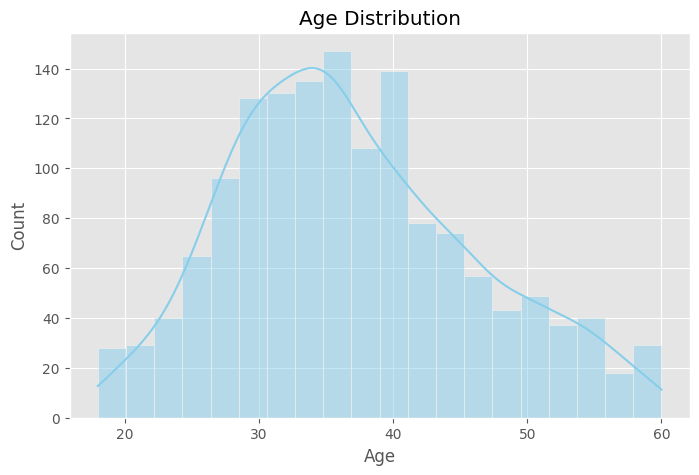

In [12]:
plt.figure(figsize=(8,5))

sns.histplot(df['Age'], bins=20, kde=True,color='skyblue')

plt.title("Age Distribution")

plt.show()

**2 Monthly Income Distribution**

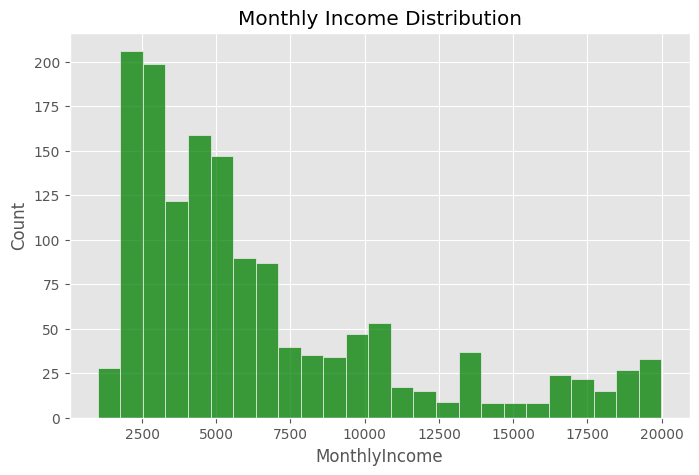

In [13]:
plt.figure(figsize=(8,5))

sns.histplot(df['MonthlyIncome'],
             bins=25,
             color='green')

plt.title("Monthly Income Distribution")

plt.show()

**3 Attrition Count**

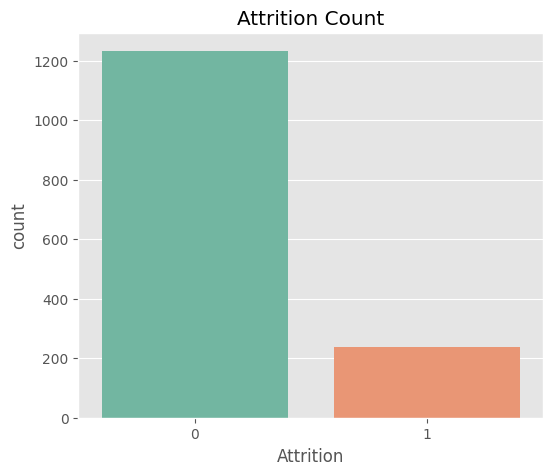

In [14]:
plt.figure(figsize=(6,5))

sns.countplot(x='Attrition',
              data=df,
              palette='Set2')

plt.title("Attrition Count")

plt.show()

**4 Gender vs Attrition**

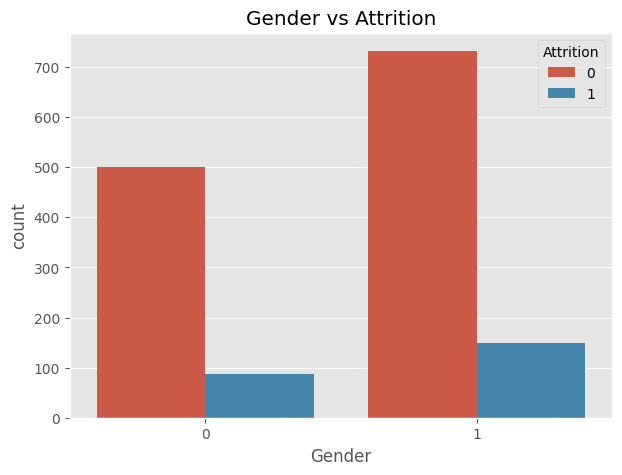

In [21]:
plt.figure(figsize=(7,5))

sns.countplot(x='Gender',
              hue='Attrition',
              data=df)

plt.title("Gender vs Attrition")

plt.show()

**5 Department vs Attrition**

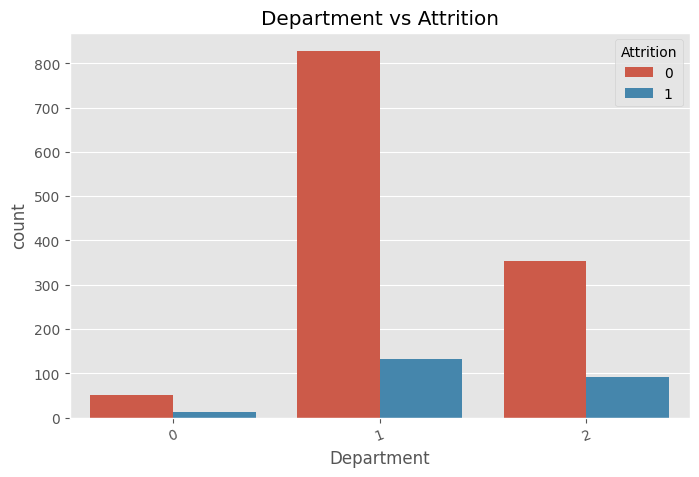

In [22]:
plt.figure(figsize=(8,5))

sns.countplot(x='Department',
              hue='Attrition',
              data=df)

plt.xticks(rotation=20)

plt.title("Department vs Attrition")

plt.show()

**6 Job Role vs Attrition**

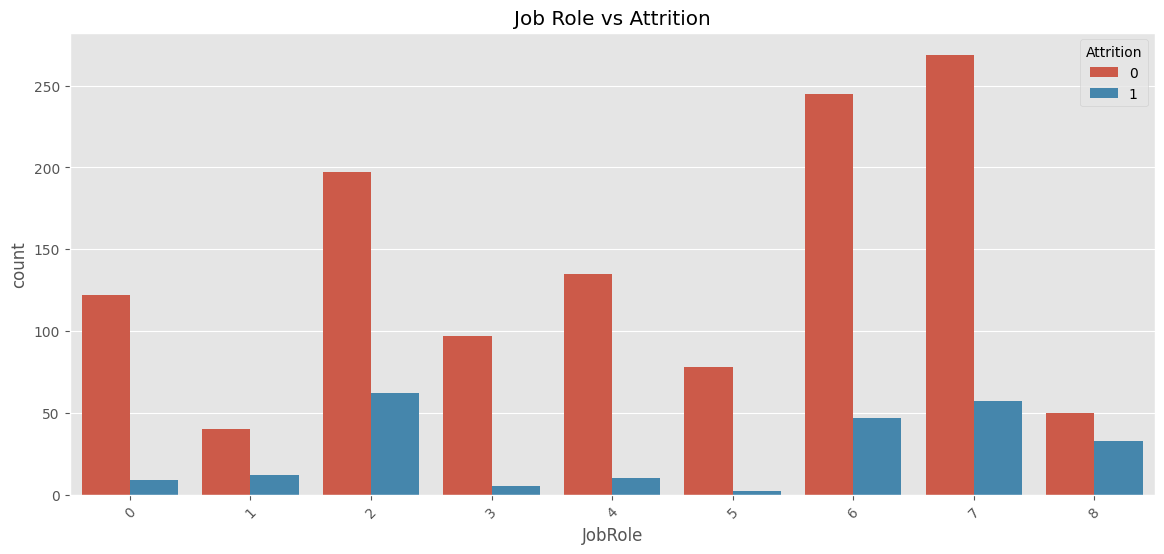

In [23]:
plt.figure(figsize=(14,6))

sns.countplot(x='JobRole',
              hue='Attrition',
              data=df)

plt.xticks(rotation=45)

plt.title("Job Role vs Attrition")

plt.show()

**7 Overtime vs Attrition**

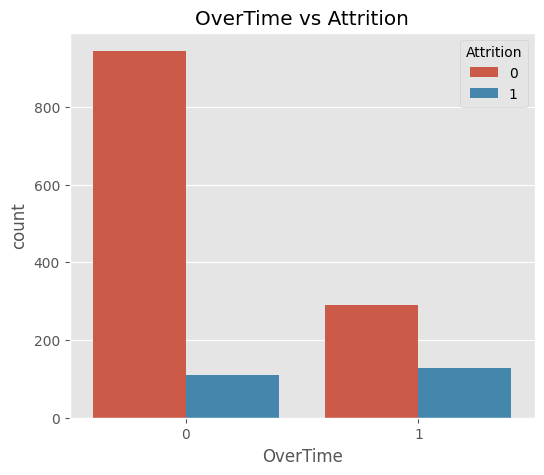

In [24]:
plt.figure(figsize=(6,5))

sns.countplot(x='OverTime',
              hue='Attrition',
              data=df)

plt.title("OverTime vs Attrition")

plt.show()

**8 Job Satisfaction**

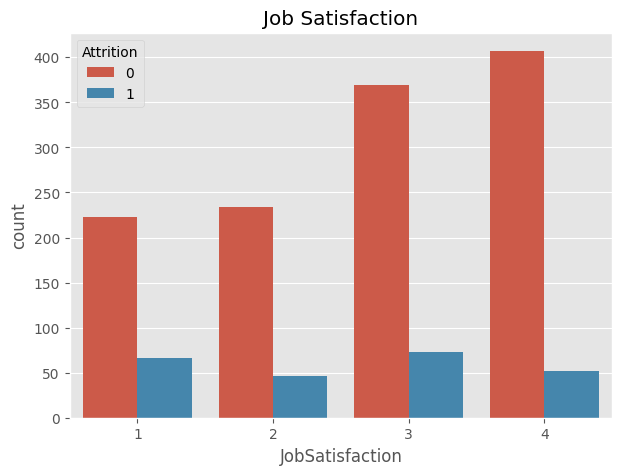

In [25]:
plt.figure(figsize=(7,5))

sns.countplot(x='JobSatisfaction',
              hue='Attrition',
              data=df)

plt.title("Job Satisfaction")

plt.show()

**9 Work Life Balance**

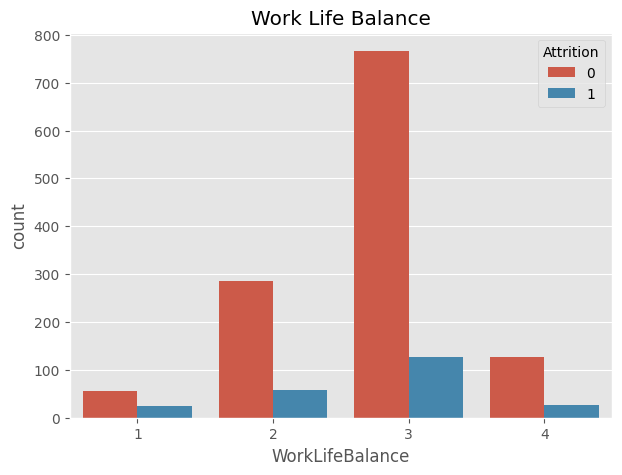

In [26]:
plt.figure(figsize=(7,5))

sns.countplot(x='WorkLifeBalance',
              hue='Attrition',
              data=df)

plt.title("Work Life Balance")

plt.show()

**10 Marital Status**

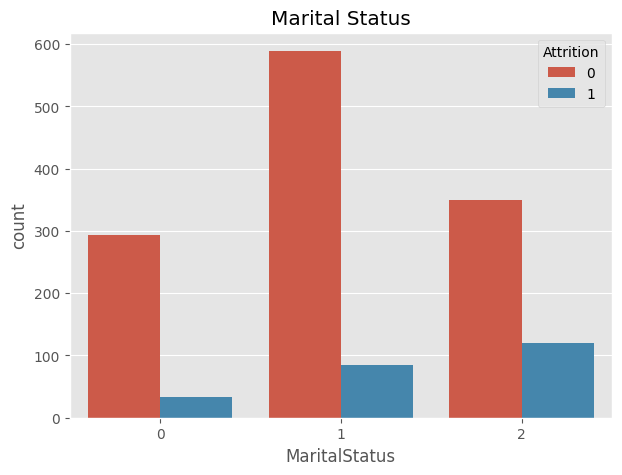

In [27]:
plt.figure(figsize=(7,5))

sns.countplot(x='MaritalStatus',
              hue='Attrition',
              data=df)

plt.title("Marital Status")

plt.show()

**11 Education Field**

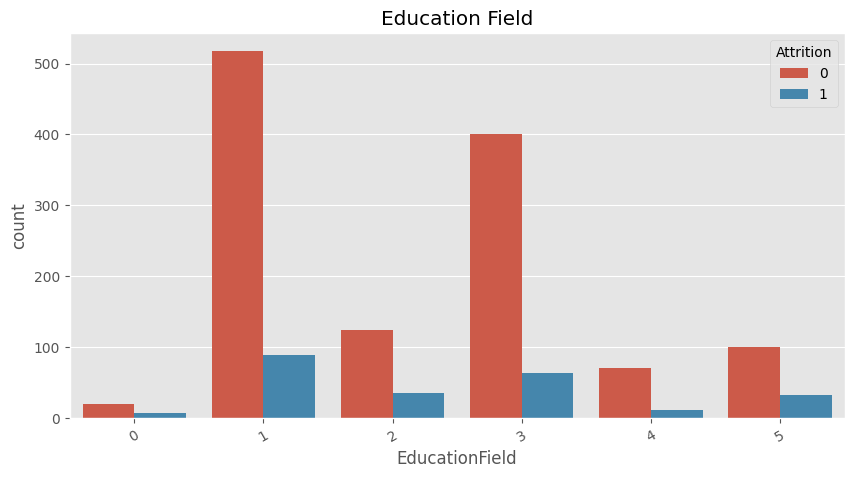

In [28]:
plt.figure(figsize=(10,5))

sns.countplot(x='EducationField',
              hue='Attrition',
              data=df)

plt.xticks(rotation=30)

plt.title("Education Field")

plt.show()

**12 Years at Company**

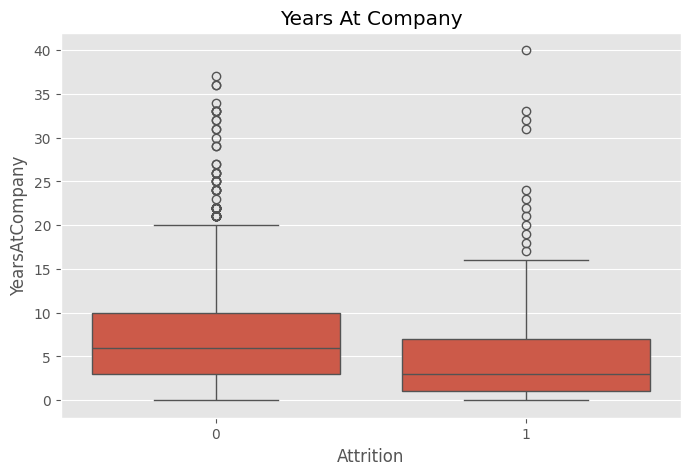

In [29]:
plt.figure(figsize=(8,5))

sns.boxplot(x='Attrition',
            y='YearsAtCompany',
            data=df)

plt.title("Years At Company")

plt.show()

**13 Monthly Income vs Attrition**

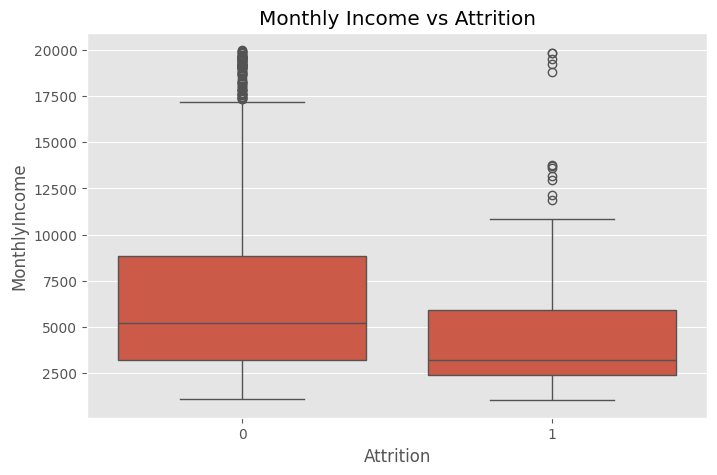

In [30]:
plt.figure(figsize=(8,5))

sns.boxplot(x='Attrition',
            y='MonthlyIncome',
            data=df)

plt.title("Monthly Income vs Attrition")

plt.show()

**14 Age vs Attrition**

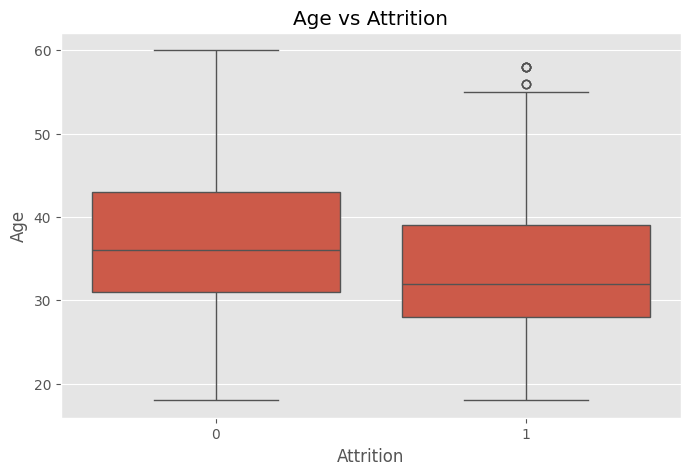

In [31]:
plt.figure(figsize=(8,5))

sns.boxplot(x='Attrition',
            y='Age',
            data=df)

plt.title("Age vs Attrition")

plt.show()

**15 Correlation Heatmap**

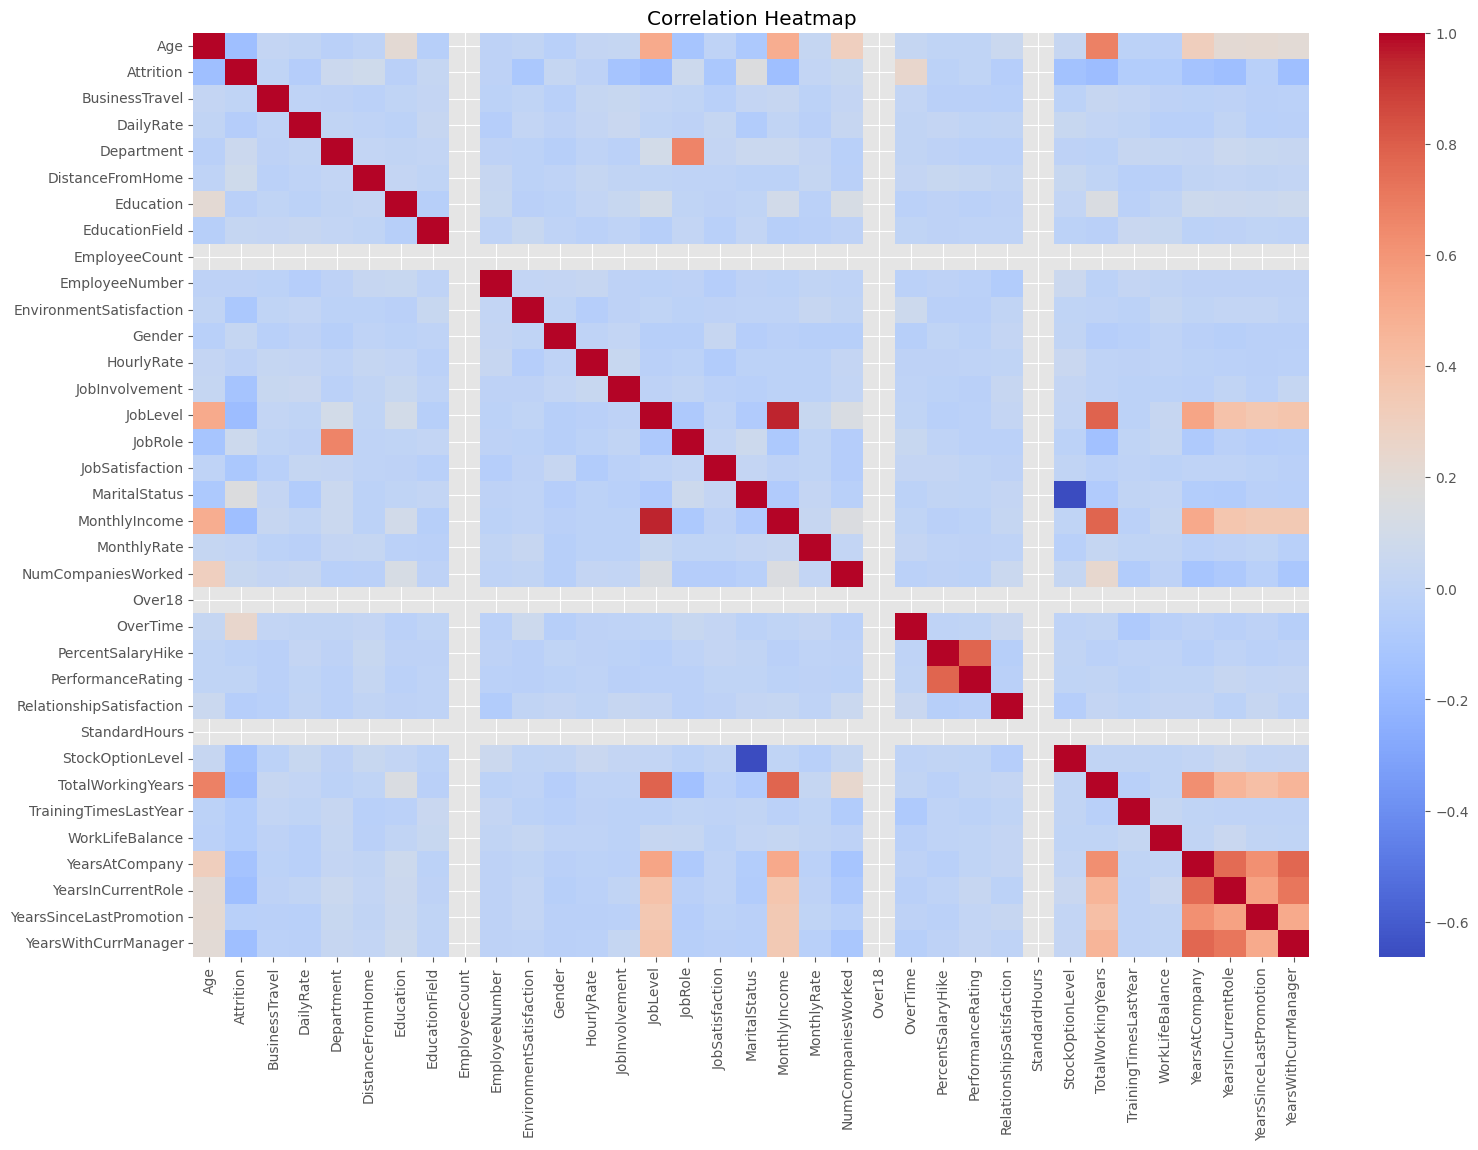

In [32]:
plt.figure(figsize=(18,12))

sns.heatmap(df.corr(),
            cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

**Feature Matrix**

In [33]:
X = df.drop('Attrition',axis=1)

y = df['Attrition']

print(X.shape)

print(y.shape)

(1470, 34)
(1470,)


**Train Test Split**

In [34]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(

    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

**Feature Scaling**

In [35]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

**Verify Shape**

In [36]:
print(X_train.shape)

print(X_test.shape)

print(y_train.shape)

print(y_test.shape)

(1176, 34)
(294, 34)
(1176,)
(294,)


**Save Scaler**

In [37]:
import joblib

joblib.dump(scaler,'scaler.pkl')

print("Scaler Saved Successfully")

Scaler Saved Successfully


**Machine Learning Models**

Machine Learning Model Building

In this section, three classification algorithms are trained and compared:

- Logistic Regression
- Decision Tree Classifier
- Random Forest Classifier

The models are evaluated using:
- Accuracy
- Confusion Matrix
- Classification Report
- ROC Curve

**1. Logistic Regression**

In [38]:
# ==============================
# Logistic Regression
# ==============================

lr = LogisticRegression(max_iter=1000, random_state=42)

lr.fit(X_train,y_train)

lr_pred = lr.predict(X_test)

lr_prob = lr.predict_proba(X_test)[:,1]

print("Model Trained Successfully")

Model Trained Successfully


**Logistic Regression Accuracy**

In [39]:
lr_accuracy = accuracy_score(y_test,lr_pred)

print("Logistic Regression Accuracy : {:.2f}%".format(lr_accuracy*100))

Logistic Regression Accuracy : 87.41%


**Confusion Matrix**

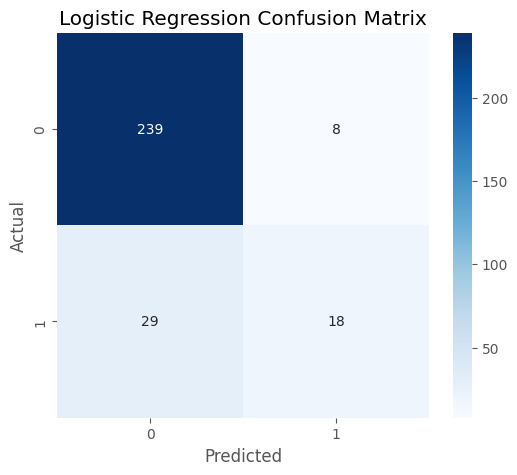

In [40]:
plt.figure(figsize=(6,5))

sns.heatmap(confusion_matrix(y_test,lr_pred),
            annot=True,
            fmt='d',
            cmap='Blues')

plt.title("Logistic Regression Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

**Classification Report**

In [41]:
print(classification_report(y_test,lr_pred))

              precision    recall  f1-score   support

           0       0.89      0.97      0.93       247
           1       0.69      0.38      0.49        47

    accuracy                           0.87       294
   macro avg       0.79      0.68      0.71       294
weighted avg       0.86      0.87      0.86       294



**2. Decision Tree**

In [42]:
# ==========================
# Decision Tree
# ==========================

dt = DecisionTreeClassifier(
    random_state=42,
    max_depth=6
)

dt.fit(X_train,y_train)

dt_pred = dt.predict(X_test)

dt_prob = dt.predict_proba(X_test)[:,1]

print("Decision Tree Trained")

Decision Tree Trained


**Accuracy**

In [43]:
dt_accuracy = accuracy_score(y_test,dt_pred)

print("Decision Tree Accuracy : {:.2f}%".format(dt_accuracy*100))

Decision Tree Accuracy : 82.31%


**Confusion Matrix**

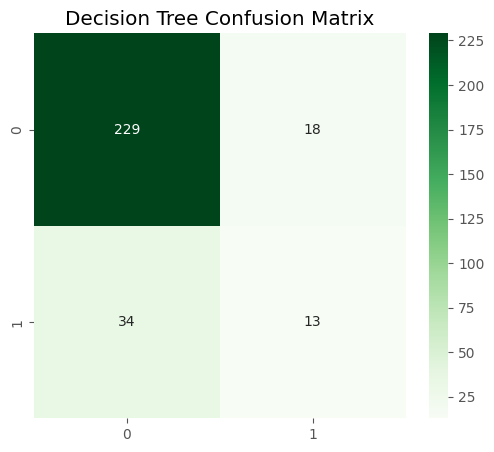

In [44]:
plt.figure(figsize=(6,5))

sns.heatmap(confusion_matrix(y_test,dt_pred),
            annot=True,
            fmt='d',
            cmap='Greens')

plt.title("Decision Tree Confusion Matrix")

plt.show()

**Classification Report**

In [45]:
print(classification_report(y_test,dt_pred))

              precision    recall  f1-score   support

           0       0.87      0.93      0.90       247
           1       0.42      0.28      0.33        47

    accuracy                           0.82       294
   macro avg       0.65      0.60      0.62       294
weighted avg       0.80      0.82      0.81       294



**3. Random Forest**

In [46]:
# =============================
# Random Forest
# =============================

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train,y_train)

rf_pred = rf.predict(X_test)

rf_prob = rf.predict_proba(X_test)[:,1]

print("Random Forest Trained")

Random Forest Trained


**Accuracy**

In [47]:
rf_accuracy = accuracy_score(y_test,rf_pred)

print("Random Forest Accuracy : {:.2f}%".format(rf_accuracy*100))

Random Forest Accuracy : 83.33%


**Confusion Matrix**

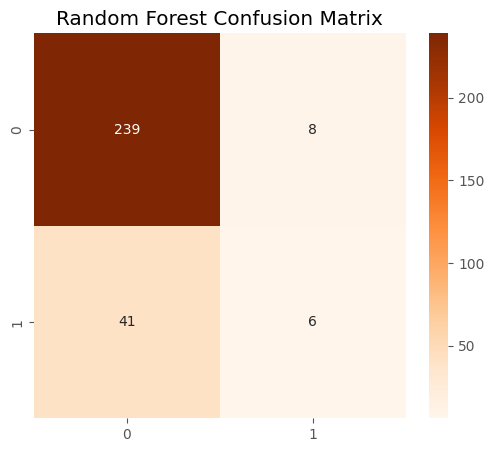

In [48]:
plt.figure(figsize=(6,5))

sns.heatmap(confusion_matrix(y_test,rf_pred),
            annot=True,
            fmt='d',
            cmap='Oranges')

plt.title("Random Forest Confusion Matrix")

plt.show()

**Classification Report**

In [49]:
print(classification_report(y_test,rf_pred))

              precision    recall  f1-score   support

           0       0.85      0.97      0.91       247
           1       0.43      0.13      0.20        47

    accuracy                           0.83       294
   macro avg       0.64      0.55      0.55       294
weighted avg       0.79      0.83      0.79       294



# Model Comparison

In [50]:
comparison = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],

    "Accuracy":[
        lr_accuracy,
        dt_accuracy,
        rf_accuracy
    ]

})

comparison

,Model,Accuracy
0,Logistic Regression,0.874150
1,Decision Tree,0.823129
2,Random Forest,0.833333


**Accuracy Graph**

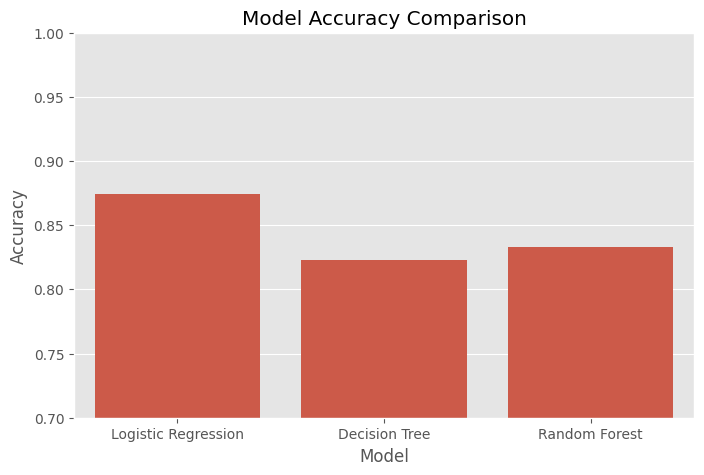

In [51]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='Model',
    y='Accuracy',
    data=comparison
)

plt.ylim(0.7,1)

plt.title("Model Accuracy Comparison")

plt.show()

**ROC Curve**

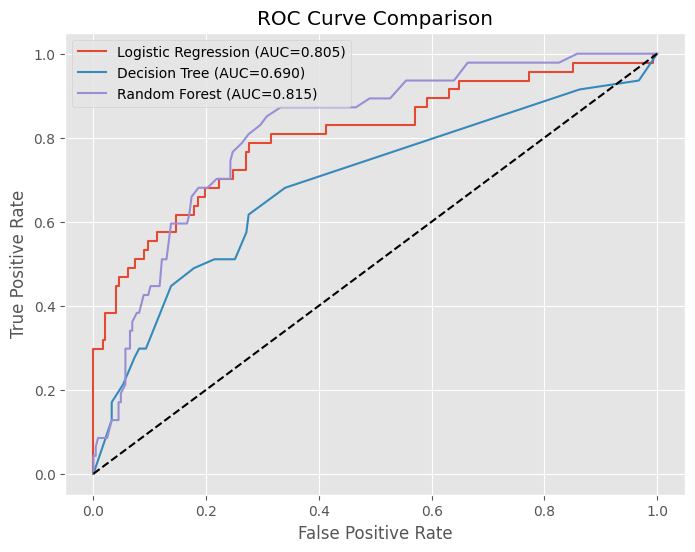

In [52]:
from sklearn.metrics import roc_curve,roc_auc_score

plt.figure(figsize=(8,6))

models = [

    ("Logistic Regression",lr_prob),

    ("Decision Tree",dt_prob),

    ("Random Forest",rf_prob)

]

for name,prob in models:

    fpr,tpr,_ = roc_curve(y_test,prob)

    auc = roc_auc_score(y_test,prob)

    plt.plot(fpr,tpr,label=f"{name} (AUC={auc:.3f})")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison")

plt.legend()

plt.show()

**Best Model**

In [53]:
best_model = comparison.sort_values(
    by='Accuracy',
    ascending=False
)

best_model

,Model,Accuracy
0,Logistic Regression,0.874150
2,Random Forest,0.833333
1,Decision Tree,0.823129


**Display Best Model**

In [54]:
print("Best Performing Model")

print(best_model.iloc[0])

Best Performing Model
Model       Logistic Regression
Accuracy                0.87415
Name: 0, dtype: object


**Feature Importance (Random Forest)**

In [55]:
importance = pd.DataFrame({

    "Feature":X.columns,

    "Importance":rf.feature_importances_

})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance.head(10)

,Feature,Importance
17,MonthlyIncome,0.073865
0,Age,0.063968
27,TotalWorkingYears,0.057061
2,DailyRate,0.054537
11,HourlyRate,0.047466
18,MonthlyRate,0.046718
4,DistanceFromHome,0.046369
8,EmployeeNumber,0.045079
21,OverTime,0.039857
30,YearsAtCompany,0.039158


**Top 10 Features**

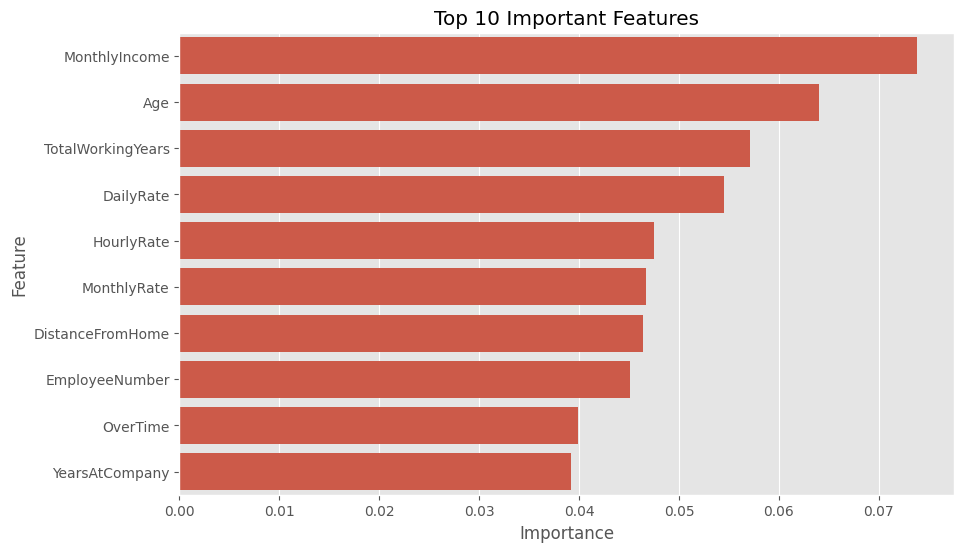

In [56]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance.head(10)
)

plt.title("Top 10 Important Features")

plt.show()

**Save Best Model**

In [57]:
import joblib

joblib.dump(rf,'employee_attrition_model.pkl')

print("Model Saved Successfully")

Model Saved Successfully


# **Employee Attrition Prediction System**

Prediction System

In this section, the trained Random Forest model is used to predict whether a new employee is likely to leave the organization.

The model also predicts the probability of attrition and displays the risk level.

**Load Saved Model**

In [58]:
import joblib

model = joblib.load("employee_attrition_model.pkl")

scaler = joblib.load("scaler.pkl")

print("Model Loaded Successfully")

Model Loaded Successfully


**Feature Names**

In [59]:
feature_names = X.columns.tolist()

print(feature_names)

['Age', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


**Sample Employee**

In [61]:
sample_employee = X.iloc[[0]]

sample_employee

,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,2,1102,2,1,2,1,1,1,2,...,1,80,0,8,0,1,6,4,0,5


**Prediction**

In [62]:
prediction = model.predict(sample_employee)

probability = model.predict_proba(sample_employee)

print(prediction)

print(probability)

[0]
[[0.555 0.445]]


**Display Result**

In [63]:
if prediction[0]==1:

    print("Employee is likely to leave the company.")

else:

    print("Employee is likely to stay with the company.")

Employee is likely to stay with the company.


**Prediction Probability**

In [64]:
leave_probability = probability[0][1]*100

stay_probability = probability[0][0]*100

print("Probability of Staying : {:.2f}%".format(stay_probability))

print("Probability of Leaving : {:.2f}%".format(leave_probability))

Probability of Staying : 55.50%
Probability of Leaving : 44.50%


**Risk Level**

In [65]:
if leave_probability<30:

    risk="LOW"

elif leave_probability<60:

    risk="MEDIUM"

else:

    risk="HIGH"

print("Risk Level :",risk)

Risk Level : MEDIUM


**Predict Any Employee**

In [66]:
employee_number = int(input("Enter Employee Row Number (0-1469): "))

employee = X.iloc[[employee_number]]

prediction = model.predict(employee)

probability = model.predict_proba(employee)

leave_probability = probability[0][1]*100

print()

print("="*50)

if prediction[0]==1:

    print("Prediction : Employee Will Leave")

else:

    print("Prediction : Employee Will Stay")

print()

print("Probability of Leaving : {:.2f}%".format(leave_probability))

print("="*50)

Enter Employee Row Number (0-1469): 999

Prediction : Employee Will Stay

Probability of Leaving : 35.00%


**Final Conclusion**

In [68]:


print("PROJECT COMPLETED SUCCESSFULLY")

print("="*60)

print()

print("Summary")

print("---------------------------")

print()

print("Dataset Used : IBM HR Analytics")

print()

print("Algorithms Used")

print("1. Logistic Regression")

print("2. Decision Tree")

print("3. Random Forest")

print()

print("Best Performing Model :")

print(best_model["Model"])

print()



PROJECT COMPLETED SUCCESSFULLY

Summary
---------------------------

Dataset Used : IBM HR Analytics

Algorithms Used
1. Logistic Regression
2. Decision Tree
3. Random Forest

Best Performing Model :
0    Logistic Regression
2          Random Forest
1          Decision Tree
Name: Model, dtype: object

